# Guía Completa: Tratamiento de Datos Faltantes

## Objetivos de Aprendizaje

En este notebook aprenderás las técnicas esenciales para manejar datos faltantes, incluyendo:

- **Identificar datos faltantes**: Detección y cuantificación de valores NaN
- **Visualizar patrones**: Análisis visual de datos faltantes
- **Estrategias de eliminación**: Cuándo y cómo eliminar filas/columnas
- **Técnicas de imputación**: Rellenar valores con estadísticos y métodos avanzados
- **Evaluación de resultados**: Validar la efectividad de las técnicas aplicadas

El manejo adecuado de datos faltantes es crucial para obtener resultados confiables en cualquier análisis de datos.

## 1. Importar Librerías Necesarias

Comenzaremos importando todas las librerías que necesitaremos para el análisis y tratamiento de datos faltantes.

In [1]:
# Librerías fundamentales
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones para visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Configurar pandas para mostrar más información
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Librerías importadas correctamente!
Pandas version: 2.2.3
NumPy version: 1.26.4


## 2. Cargar y Explorar el Dataset

Crearemos un dataset de ejemplo con datos faltantes para practicar las diferentes técnicas de tratamiento.

In [2]:
# Crear un dataset de ejemplo con datos faltantes
np.random.seed(42)

data = {
    'id': range(1, 101),
    'nombre'       : [f'Empleado_{i}' if i % 7 != 0 else np.nan for i in range(1, 101)],
    'edad'         :  [np.random.randint(22, 65) if i % 5 != 0 else np.nan for i in range(100)],
    'salario'      : [np.random.normal(50000, 15000) if i % 8 != 0 else np.nan for i in range(100)],
    'departamento' : [np.random.choice(['IT', 'Ventas', 'Marketing', 'RRHH']) if i % 6 != 0 else np.nan for i in range(100)],
    'experiencia'  : [np.random.randint(0, 20) if i % 4 != 0 else np.nan for i in range(100)],
    'evaluacion'   : [np.random.uniform(1, 10) if i % 10 != 0 else np.nan for i in range(100)],
    'fecha_ingreso': pd.date_range(start='2020-01-01', periods=100, freq='D')
}

df_original = pd.DataFrame(data)

print("Dataset creado con éxito!")
print(f"Forma del dataset: {df_original.shape}")
print("\nPrimeras 10 filas:")
df_original.head(10)

Dataset creado con éxito!
Forma del dataset: (100, 8)

Primeras 10 filas:


,id,nombre,edad,salario,departamento,experiencia,evaluacion,fecha_ingreso
0,1,Empleado_1,NaN,NaN,NaN,NaN,NaN,2020-01-01
1,2,Empleado_2,60.0,58731.841921,RRHH,15.0,4.946267,2020-01-02
2,3,Empleado_3,50.0,63316.226894,IT,19.0,7.048235,2020-01-03
3,4,Empleado_4,36.0,63414.984952,IT,7.0,3.953374,2020-01-04
4,5,Empleado_5,64.0,61324.966959,RRHH,NaN,2.395375,2020-01-05
5,6,Empleado_6,NaN,46892.511648,RRHH,6.0,9.836568,2020-01-06
6,7,NaN,29.0,40647.839075,NaN,2.0,8.550402,2020-01-07
7,8,Empleado_8,42.0,27377.700657,Marketing,16.0,8.743642,2020-01-08
8,9,Empleado_9,60.0,NaN,Ventas,NaN,3.252262,2020-01-09
9,10,Empleado_10,40.0,66494.704637,RRHH,0.0,1.349513,2020-01-10


In [3]:
# Información general del dataset
print("Información del dataset:")
display(df_original.info())
print("\nEstadísticas descriptivas:")
display(df_original.describe())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             100 non-null    int64         
 1   nombre         86 non-null     object        
 2   edad           80 non-null     float64       
 3   salario        87 non-null     float64       
 4   departamento   83 non-null     object        
 5   experiencia    75 non-null     float64       
 6   evaluacion     90 non-null     float64       
 7   fecha_ingreso  100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 6.4+ KB


None


Estadísticas descriptivas:


,id,edad,salario,experiencia,evaluacion,fecha_ingreso
count,100.000000,80.000000,87.000000,75.000000,90.000000,100
mean,50.500000,42.487500,50994.841548,9.040000,5.385014,2020-02-19 12:00:00
min,1.000000,23.000000,10172.359287,0.000000,1.137741,2020-01-01 00:00:00
25%,25.750000,32.750000,43054.686779,2.500000,2.877945,2020-01-25 18:00:00
50%,50.500000,42.500000,50059.059566,9.000000,5.148725,2020-02-19 12:00:00
75%,75.250000,50.250000,61553.282709,15.000000,7.664876,2020-03-15 06:00:00
max,100.000000,64.000000,100584.443804,19.000000,9.836568,2020-04-09 00:00:00
std,29.011492,12.003158,14229.505967,6.261077,2.724221,NaN


## 3. Identificar Datos Faltantes

Usaremos varios métodos para identificar y cuantificar los valores faltantes en nuestro dataset.

In [4]:
# Verificar valores nulos usando isnull()
print("¿Hay valores nulos? (Usando isnull()):")
display(df_original.isnull().any())
print("\nNúmero de valores nulos por columna:")
display(df_original.isnull().sum())

¿Hay valores nulos? (Usando isnull()):


id               False
nombre            True
edad              True
salario           True
departamento      True
experiencia       True
evaluacion        True
fecha_ingreso    False
dtype: bool


Número de valores nulos por columna:


id                0
nombre           14
edad             20
salario          13
departamento     17
experiencia      25
evaluacion       10
fecha_ingreso     0
dtype: int64

In [5]:
# Porcentaje de valores faltantes
porcentaje_faltantes = (df_original.isnull().sum() / len(df_original)) * 100
print("Porcentaje de valores faltantes por columna:")
print(porcentaje_faltantes.round(2))

# Crear un resumen más detallado
resumen_faltantes = pd.DataFrame({
    'Columna': df_original.columns,
    'Valores_Faltantes': df_original.isnull().sum(),
    'Porcentaje': porcentaje_faltantes.round(2),
    'Tipo_Dato': df_original.dtypes
})
print("\nResumen detallado de datos faltantes:")
display(resumen_faltantes)

Porcentaje de valores faltantes por columna:
id                0.0
nombre           14.0
edad             20.0
salario          13.0
departamento     17.0
experiencia      25.0
evaluacion       10.0
fecha_ingreso     0.0
dtype: float64

Resumen detallado de datos faltantes:


,Columna,Valores_Faltantes,Porcentaje,Tipo_Dato
id,id,0,0.0,int64
nombre,nombre,14,14.0,object
edad,edad,20,20.0,float64
salario,salario,13,13.0,float64
departamento,departamento,17,17.0,object
experiencia,experiencia,25,25.0,float64
evaluacion,evaluacion,10,10.0,float64
fecha_ingreso,fecha_ingreso,0,0.0,datetime64[ns]


In [6]:
# Identificar filas con al menos un valor faltante
filas_con_nulos = df_original.isnull().any(axis=1)

print(f"Número de filas con al menos un valor faltante: {filas_con_nulos.sum()}")

print(f"Porcentaje de filas afectadas: {(filas_con_nulos.sum() / len(df_original)) * 100:.2f}%")

# Mostrar algunas filas con valores faltantes
print("\nEjemplo de filas con valores faltantes:")

display(df_original[filas_con_nulos].head())

Número de filas con al menos un valor faltante: 54
Porcentaje de filas afectadas: 54.00%

Ejemplo de filas con valores faltantes:


,id,nombre,edad,salario,departamento,experiencia,evaluacion,fecha_ingreso
0,1,Empleado_1,NaN,NaN,NaN,NaN,NaN,2020-01-01
4,5,Empleado_5,64.0,61324.966959,RRHH,NaN,2.395375,2020-01-05
5,6,Empleado_6,NaN,46892.511648,RRHH,6.0,9.836568,2020-01-06
6,7,NaN,29.0,40647.839075,NaN,2.0,8.550402,2020-01-07
8,9,Empleado_9,60.0,NaN,Ventas,NaN,3.252262,2020-01-09


## 4. Visualizar Patrones de Datos Faltantes

Las visualizaciones nos ayudan a entender mejor los patrones de datos faltantes y tomar decisiones informadas.

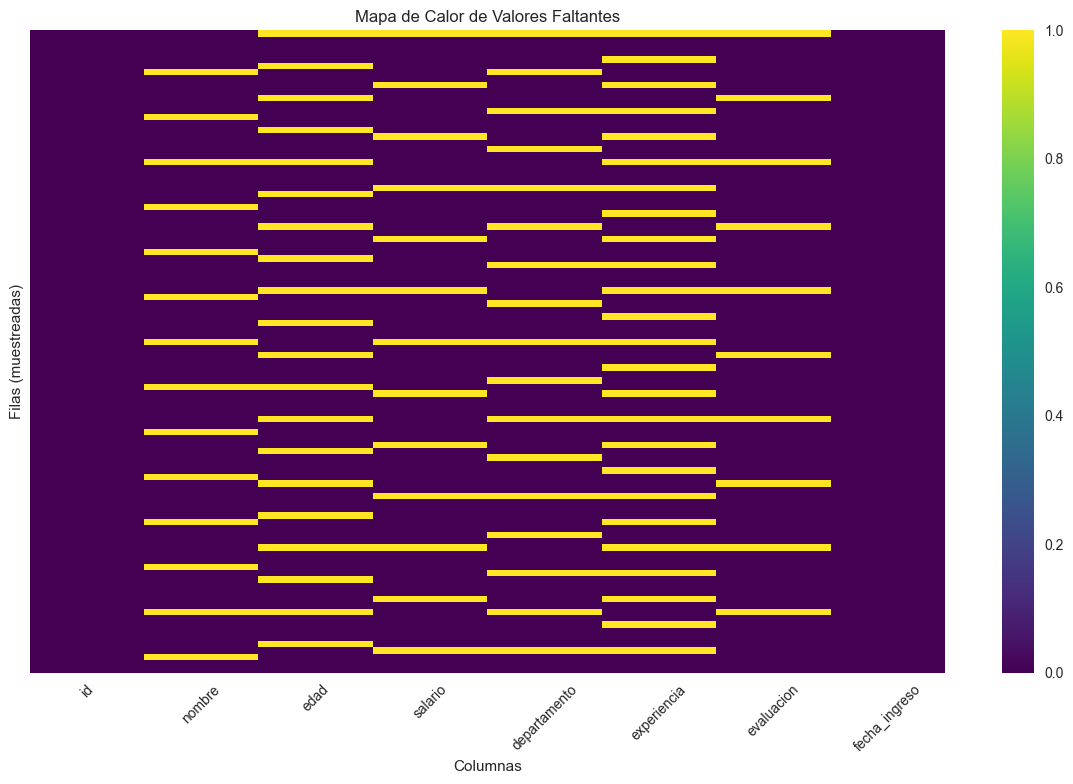

In [8]:
# Mapa de calor de valores faltantes
plt.figure(figsize=(12, 8))
sns.heatmap(df_original.isnull(), 
            yticklabels=False, 
            cbar=True, 
            cmap='viridis',
            xticklabels=True)
plt.title('Mapa de Calor de Valores Faltantes')
plt.xlabel('Columnas')
plt.ylabel('Filas (muestreadas)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

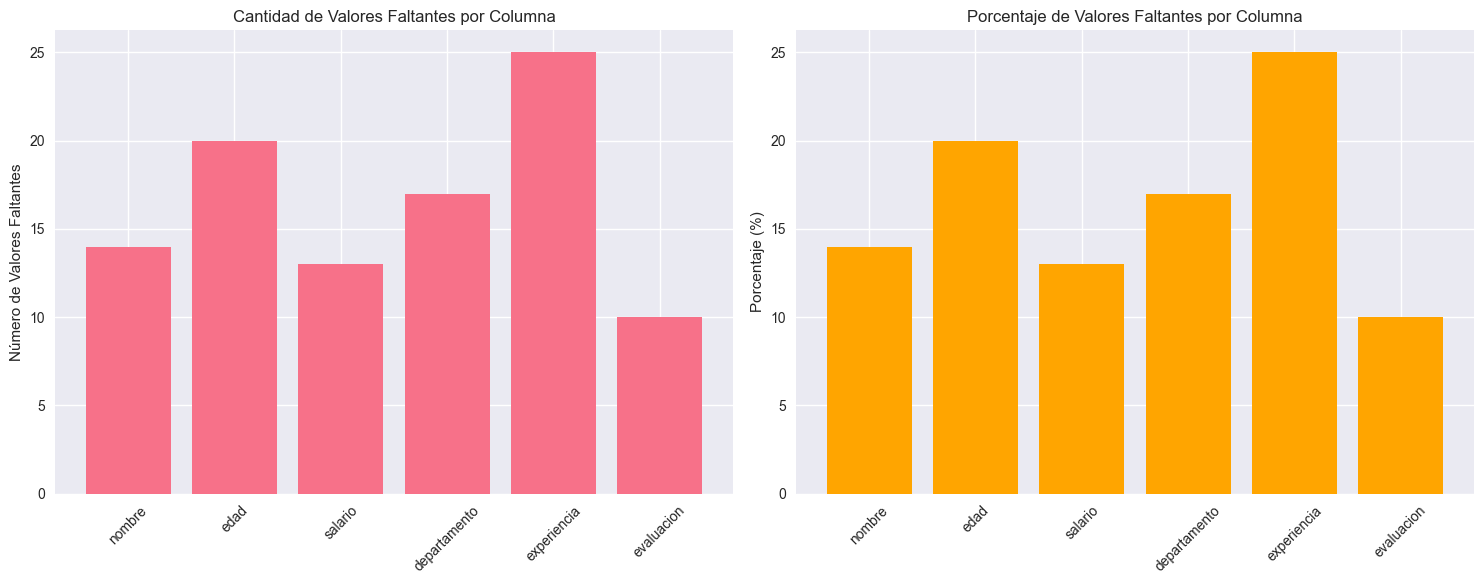

In [9]:
# Gráfico de barras de valores faltantes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


# Gráfico de conteo absoluto

valores_faltantes = df_original.isnull().sum()
valores_faltantes = valores_faltantes[valores_faltantes > 0]
ax1.bar(range(len(valores_faltantes)), valores_faltantes.values)
ax1.set_xticks(range(len(valores_faltantes)))
ax1.set_xticklabels(valores_faltantes.index, rotation=45)
ax1.set_title('Cantidad de Valores Faltantes por Columna')
ax1.set_ylabel('Número de Valores Faltantes')

# Gráfico de porcentajes
porcentajes = (valores_faltantes / len(df_original)) * 100
ax2.bar(range(len(porcentajes)), porcentajes.values, color='orange')
ax2.set_xticks(range(len(porcentajes)))
ax2.set_xticklabels(porcentajes.index, rotation=45)
ax2.set_title('Porcentaje de Valores Faltantes por Columna')
ax2.set_ylabel('Porcentaje (%)')

plt.tight_layout()
plt.show()

## 5. Eliminar Filas o Columnas con Datos Faltantes

A veces la mejor estrategia es eliminar datos faltantes. Veamos diferentes enfoques.

In [10]:
# Crear una copia para experimentar con eliminación
df_eliminacion = df_original.copy()

print(f"Dataset original: {df_eliminacion.shape}")

# 1. Eliminar filas con CUALQUIER valor faltante
df_sin_nulos = df_eliminacion.dropna()

print(f"Después de eliminar filas con cualquier nulo: {df_sin_nulos.shape}")
print(f"Filas eliminadas: {len(df_eliminacion) - len(df_sin_nulos)}")


Dataset original: (100, 8)
Después de eliminar filas con cualquier nulo: (46, 8)
Filas eliminadas: 54


In [11]:

# 2. Eliminar filas solo si TODOS los valores son nulos
df_sin_todas_nulas = df_eliminacion.dropna(how='all')
print(f"Después de eliminar filas completamente nulas: {df_sin_todas_nulas.shape}")


Después de eliminar filas completamente nulas: (100, 8)


In [13]:
df_eliminacion.dropna?

Signature:
df_eliminacion.dropna(
    *,
    axis: 'Axis' = 0,
    how: 'AnyAll | lib.NoDefault' = <no_default>,
    thresh: 'int | lib.NoDefault' = <no_default>,
    subset: 'IndexLabel | None' = None,
    inplace: 'bool' = False,
    ignore_index: 'bool' = False,
) -> 'DataFrame | None'
Docstring:
Remove missing values.

See the :ref:`User Guide <missing_data>` for more on which values are
considered missing, and how to work with missing data.

Parameters
----------
axis : {0 or 'index', 1 or 'columns'}, default 0
    Determine if rows or columns which contain missing values are
    removed.

    * 0, or 'index' : Drop rows which contain missing values.
    * 1, or 'columns' : Drop columns which contain missing value.

    Only a single axis is allowed.

how : {'any', 'all'}, default 'any'
    Determine if row or column is removed from DataFrame, when we have
    at least one NA or all NA.

    * 'any' : If any NA values are present, drop that row or column.
    * 'all' : If all valu

In [12]:

# 3. Eliminar filas con menos de X valores válidos
df_min_valores = df_eliminacion.dropna(thresh=5)  # Al menos 5 valores no nulos
print(f"Después de requerir al menos 5 valores válidos: {df_min_valores.shape}")

Después de requerir al menos 5 valores válidos: (93, 8)


In [14]:
# Eliminar columnas con muchos valores faltantes
print("Análisis de columnas para posible eliminación:")
porcentaje_por_columna = (df_original.isnull().sum() / len(df_original)) * 100
display(porcentaje_por_columna.sort_values(ascending=False))


Análisis de columnas para posible eliminación:


experiencia      25.0
edad             20.0
departamento     17.0
nombre           14.0
salario          13.0
evaluacion       10.0
id                0.0
fecha_ingreso     0.0
dtype: float64

In [16]:
df_original.drop?

Signature:
df_original.drop(
    labels: 'IndexLabel | None' = None,
    *,
    axis: 'Axis' = 0,
    index: 'IndexLabel | None' = None,
    columns: 'IndexLabel | None' = None,
    level: 'Level | None' = None,
    inplace: 'bool' = False,
    errors: 'IgnoreRaise' = 'raise',
) -> 'DataFrame | None'
Docstring:
Drop specified labels from rows or columns.

Remove rows or columns by specifying label names and corresponding
axis, or by directly specifying index or column names. When using a
multi-index, labels on different levels can be removed by specifying
the level. See the :ref:`user guide <advanced.shown_levels>`
for more information about the now unused levels.

Parameters
----------
labels : single label or list-like
    Index or column labels to drop. A tuple will be used as a single
    label and not treated as a list-like.
axis : {0 or 'index', 1 or 'columns'}, default 0
    Whether to drop labels from the index (0 or 'index') or
    columns (1 or 'columns').
index : single labe

In [15]:

# Eliminar columnas con más del 30% de valores faltantes
umbral = 30
columnas_a_eliminar = porcentaje_por_columna[porcentaje_por_columna > umbral].index
print(f"\nColumnas con más de {umbral}% de valores faltantes: {list(columnas_a_eliminar)}")

if len(columnas_a_eliminar) > 0:
    df_sin_columnas_problematicas = df_original.drop(columns=columnas_a_eliminar)
    print(f"Después de eliminar columnas problemáticas: {df_sin_columnas_problematicas.shape}")
else:
    df_sin_columnas_problematicas = df_original.copy()
    print("No hay columnas que superen el umbral de eliminación.")

# Eliminar solo columnas específicas
df_sin_evaluacion = df_original.drop(columns=['evaluacion'])
print(f"Después de eliminar 'evaluacion': {df_sin_evaluacion.shape}")


Columnas con más de 30% de valores faltantes: []
No hay columnas que superen el umbral de eliminación.
Después de eliminar 'evaluacion': (100, 7)


## 6. Imputación con Valores Estadísticos

La imputación permite mantener las filas rellenando los valores faltantes con estadísticos apropiados.

In [17]:
# Crear una copia para experimentar con imputación
df_imputado = df_original.copy()

print("Estadísticas antes de la imputación:")
print(f"Valores faltantes en 'edad': {df_imputado['edad'].isnull().sum()}")
print(f"Valores faltantes en 'salario': {df_imputado['salario'].isnull().sum()}")


Estadísticas antes de la imputación:
Valores faltantes en 'edad': 20
Valores faltantes en 'salario': 13


In [18]:

# 1. Imputar edad con la mediana (robust para outliers)
mediana_edad = df_imputado['edad'].median()
df_imputado['edad'].fillna(mediana_edad, inplace=True)
print(f"\nEdad imputada con mediana: {mediana_edad}")



Edad imputada con mediana: 42.5


In [19]:

# 2. Imputar salario con la media
media_salario = df_imputado['salario'].mean()
df_imputado['salario'].fillna(media_salario, inplace=True)
print(f"Salario imputado con media: {media_salario:.2f}")


Salario imputado con media: 50994.84


In [21]:

# 3. Imputar experiencia con mediana
mediana_experiencia = df_imputado['experiencia'].median()
df_imputado['experiencia'].fillna(mediana_experiencia, inplace=True)
print(f"Experiencia imputada con mediana: {mediana_experiencia}")


Experiencia imputada con mediana: 9.0


In [22]:

print(f"\nDespués de imputación:")
print(f"Valores faltantes en 'edad': {df_imputado['edad'].isnull().sum()}")
print(f"Valores faltantes en 'salario': {df_imputado['salario'].isnull().sum()}")
print(f"Valores faltantes en 'experiencia': {df_imputado['experiencia'].isnull().sum()}")


Después de imputación:
Valores faltantes en 'edad': 0
Valores faltantes en 'salario': 0
Valores faltantes en 'experiencia': 0


In [23]:
# Imputar variables categóricas con la moda
print("Tratamiento de variables categóricas:")

# Encontrar la moda del departamento
moda_departamento = df_imputado['departamento'].mode()[0]
print(f"Moda de departamento: {moda_departamento}")


Tratamiento de variables categóricas:
Moda de departamento: RRHH


In [24]:

# Imputar departamento con la moda
df_imputado['departamento'].fillna(moda_departamento, inplace=True)
print(f"Valores faltantes en departamento después de imputar: {df_imputado['departamento'].isnull().sum()}")


Valores faltantes en departamento después de imputar: 0


In [25]:

# Para nombres, usar un valor específico
df_imputado['nombre'].fillna('Sin_nombre', inplace=True)
print(f"Valores faltantes en nombre después de imputar: {df_imputado['nombre'].isnull().sum()}")


Valores faltantes en nombre después de imputar: 0


In [26]:

# Verificar distribución de departamentos después de imputación
print("\nDistribución de departamentos después de imputación:")
print(df_imputado['departamento'].value_counts())


Distribución de departamentos después de imputación:
departamento
RRHH         46
IT           22
Ventas       17
Marketing    15
Name: count, dtype: int64


## 7. Imputación Avanzada

Exploraremos técnicas más sofisticadas para tratar valores faltantes.

In [27]:
pd.DataFrame.fillna?

Signature:
pd.DataFrame.fillna(
    self,
    value: 'Hashable | Mapping | Series | DataFrame | None' = None,
    *,
    method: 'FillnaOptions | None' = None,
    axis: 'Axis | None' = None,
    inplace: 'bool_t' = False,
    limit: 'int | None' = None,
    downcast: 'dict | None | lib.NoDefault' = <no_default>,
) -> 'Self | None'
Docstring:
Fill NA/NaN values using the specified method.

Parameters
----------
value : scalar, dict, Series, or DataFrame
    Value to use to fill holes (e.g. 0), alternately a
    dict/Series/DataFrame of values specifying which value to use for
    each index (for a Series) or column (for a DataFrame).  Values not
    in the dict/Series/DataFrame will not be filled. This value cannot
    be a list.
method : {'backfill', 'bfill', 'ffill', None}, default None
    Method to use for filling holes in reindexed Series:

    * ffill: propagate last valid observation forward to next valid.
    * backfill / bfill: use next valid observation to fill gap.

    .. d

In [28]:
# Crear dataset con valores faltantes para técnicas avanzadas
df_avanzado = df_original.copy()

# 1. Forward Fill (llenar hacia adelante)
df_ff = df_avanzado.copy()
df_ff['evaluacion'] = df_ff['evaluacion'].fillna(method='ffill')
print("Forward Fill - Primeros valores de evaluación:")
print(df_ff['evaluacion'].head(15))


Forward Fill - Primeros valores de evaluación:
0          NaN
1     4.946267
2     7.048235
3     3.953374
4     2.395375
        ...   
10    1.349513
11    3.729390
12    5.833742
13    3.939861
14    8.450821
Name: evaluacion, Length: 15, dtype: float64


In [29]:

# 2. Backward Fill (llenar hacia atrás)
df_bf = df_avanzado.copy()
df_bf['evaluacion'] = df_bf['evaluacion'].fillna(method='bfill')
print("\nBackward Fill - Primeros valores de evaluación:")
print(df_bf['evaluacion'].head(15))


Backward Fill - Primeros valores de evaluación:
0     4.946267
1     4.946267
2     7.048235
3     3.953374
4     2.395375
        ...   
10    3.729390
11    3.729390
12    5.833742
13    3.939861
14    8.450821
Name: evaluacion, Length: 15, dtype: float64


In [30]:
# 3. Interpolación lineal para datos numéricos
df_interp = df_avanzado.copy()

# Crear una serie temporal ordenada para mejor interpolación
df_interp = df_interp.sort_values('id').reset_index(drop=True)
df_interp['salario'] = df_interp['salario'].interpolate(method='linear')
df_interp['edad'] = df_interp['edad'].interpolate(method='linear')

print("Interpolación lineal aplicada a salario y edad")
print("Comparación de métodos para los primeros 20 registros:")
comparacion = pd.DataFrame({
    'Original_Salario': df_original['salario'].head(20),
    'Interpolado_Salario': df_interp['salario'].head(20),
    'Original_Edad': df_original['edad'].head(20),
    'Interpolada_Edad': df_interp['edad'].head(20)
})
print(comparacion)

Interpolación lineal aplicada a salario y edad
Comparación de métodos para los primeros 20 registros:
    Original_Salario  Interpolado_Salario  Original_Edad  Interpolada_Edad
0                NaN                  NaN            NaN               NaN
1       58731.841921         58731.841921           60.0              60.0
2       63316.226894         63316.226894           50.0              50.0
3       63414.984952         63414.984952           36.0              36.0
4       61324.966959         61324.966959           64.0              64.0
..               ...                  ...            ...               ...
15      54448.420765         54448.420765            NaN              51.0
16               NaN         44440.486309           57.0              57.0
17      34432.551852         34432.551852           61.0              61.0
18      48862.943825         48862.943825           45.0              45.0
19      64594.453006         64594.453006           24.0              24.

In [16]:
# 4. Imputación por grupos (Group-based imputation)
df_grupos = df_original.copy()

print("Imputación por grupos - Salario promedio por departamento:")
# Calcular salario promedio por departamento
salario_por_depto = df_grupos.groupby('departamento')['salario'].mean()
print(salario_por_depto)

# Función para imputar salario basado en departamento
def imputar_por_departamento(row):
    if pd.isna(row['salario']) and pd.notna(row['departamento']):
        return salario_por_depto[row['departamento']]
    return row['salario']

# Aplicar imputación por departamento
df_grupos['salario_imputado'] = df_grupos.apply(imputar_por_departamento, axis=1)

# Mostrar ejemplo de imputación
ejemplo_imputacion = df_grupos[['departamento', 'salario', 'salario_imputado']].head(20)
print("\nEjemplo de imputación por departamento:")
print(ejemplo_imputacion)

Imputación por grupos - Salario promedio por departamento:
departamento
IT           54086.863802
Marketing    51051.345565
RRHH         49103.299092
Ventas       49722.123599
Name: salario, dtype: float64

Ejemplo de imputación por departamento:
   departamento       salario  salario_imputado
0           NaN           NaN               NaN
1          RRHH  58731.841921      58731.841921
2            IT  63316.226894      63316.226894
3            IT  63414.984952      63414.984952
4          RRHH  61324.966959      61324.966959
..          ...           ...               ...
15           IT  54448.420765      54448.420765
16       Ventas           NaN      49722.123599
17    Marketing  34432.551852      34432.551852
18          NaN  48862.943825      48862.943825
19    Marketing  64594.453006      64594.453006

[20 rows x 3 columns]


## 8. Verificar Resultados

Es importante evaluar la efectividad de nuestras técnicas de tratamiento de datos faltantes.

In [31]:
# Función para crear reporte de valores faltantes
def reporte_valores_faltantes(df, nombre_df):
    print(f"\n=== REPORTE PARA {nombre_df} ===")
    print(f"Forma del dataset: {df.shape}")
    
    valores_faltantes = df.isnull().sum()
    total_valores = len(df)
    porcentaje = (valores_faltantes / total_valores) * 100
    
    reporte = pd.DataFrame({
        'Columna': df.columns,
        'Valores_Faltantes': valores_faltantes,
        'Porcentaje': porcentaje.round(2),
        'Valores_Completos': total_valores - valores_faltantes
    })
    
    # Mostrar solo columnas con valores faltantes
    reporte_filtrado = reporte[reporte['Valores_Faltantes'] > 0]
    
    if len(reporte_filtrado) > 0:
        print("Columnas con valores faltantes:")
        print(reporte_filtrado)
    else:
        print("¡No hay valores faltantes en el dataset!")
    
    return reporte

# Comparar diferentes enfoques
print("COMPARACIÓN DE DIFERENTES ENFOQUES DE TRATAMIENTO")
print("=" * 60)

reporte_original = reporte_valores_faltantes(df_original, "DATASET ORIGINAL")
reporte_imputado = reporte_valores_faltantes(df_imputado, "DATASET CON IMPUTACIÓN ESTADÍSTICA")

COMPARACIÓN DE DIFERENTES ENFOQUES DE TRATAMIENTO

=== REPORTE PARA DATASET ORIGINAL ===
Forma del dataset: (100, 8)
Columnas con valores faltantes:
                   Columna  Valores_Faltantes  Porcentaje  Valores_Completos
nombre              nombre                 14        14.0                 86
edad                  edad                 20        20.0                 80
salario            salario                 13        13.0                 87
departamento  departamento                 17        17.0                 83
experiencia    experiencia                 25        25.0                 75
evaluacion      evaluacion                 10        10.0                 90

=== REPORTE PARA DATASET CON IMPUTACIÓN ESTADÍSTICA ===
Forma del dataset: (100, 8)
Columnas con valores faltantes:
               Columna  Valores_Faltantes  Porcentaje  Valores_Completos
evaluacion  evaluacion                 10        10.0                 90


In [18]:
# Comparar estadísticas descriptivas antes y después del tratamiento
print("\nCOMPARACIÓN DE ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)

# Solo para columnas numéricas
cols_numericas = ['edad', 'salario', 'experiencia', 'evaluacion']

for col in cols_numericas:
    if col in df_original.columns:
        print(f"\n--- {col.upper()} ---")
        print("Original:")
        print(f"  Media: {df_original[col].mean():.2f}")
        print(f"  Mediana: {df_original[col].median():.2f}")
        print(f"  Desv. Estándar: {df_original[col].std():.2f}")
        print(f"  Valores faltantes: {df_original[col].isnull().sum()}")
        
        if col in df_imputado.columns:
            print("Después de imputación:")
            print(f"  Media: {df_imputado[col].mean():.2f}")
            print(f"  Mediana: {df_imputado[col].median():.2f}")
            print(f"  Desv. Estándar: {df_imputado[col].std():.2f}")
            print(f"  Valores faltantes: {df_imputado[col].isnull().sum()}")


COMPARACIÓN DE ESTADÍSTICAS DESCRIPTIVAS

--- EDAD ---
Original:
  Media: 42.49
  Mediana: 42.50
  Desv. Estándar: 12.00
  Valores faltantes: 20
Después de imputación:
  Media: 42.49
  Mediana: 42.50
  Desv. Estándar: 10.72
  Valores faltantes: 0

--- SALARIO ---
Original:
  Media: 50994.84
  Mediana: 50059.06
  Desv. Estándar: 14229.51
  Valores faltantes: 13
Después de imputación:
  Media: 50994.84
  Mediana: 50994.84
  Desv. Estándar: 13262.38
  Valores faltantes: 0

--- EXPERIENCIA ---
Original:
  Media: 9.04
  Mediana: 9.00
  Desv. Estándar: 6.26
  Valores faltantes: 25
Después de imputación:
  Media: 9.03
  Mediana: 9.00
  Desv. Estándar: 5.41
  Valores faltantes: 0

--- EVALUACION ---
Original:
  Media: 5.39
  Mediana: 5.15
  Desv. Estándar: 2.72
  Valores faltantes: 10
Después de imputación:
  Media: 5.39
  Mediana: 5.15
  Desv. Estándar: 2.72
  Valores faltantes: 10


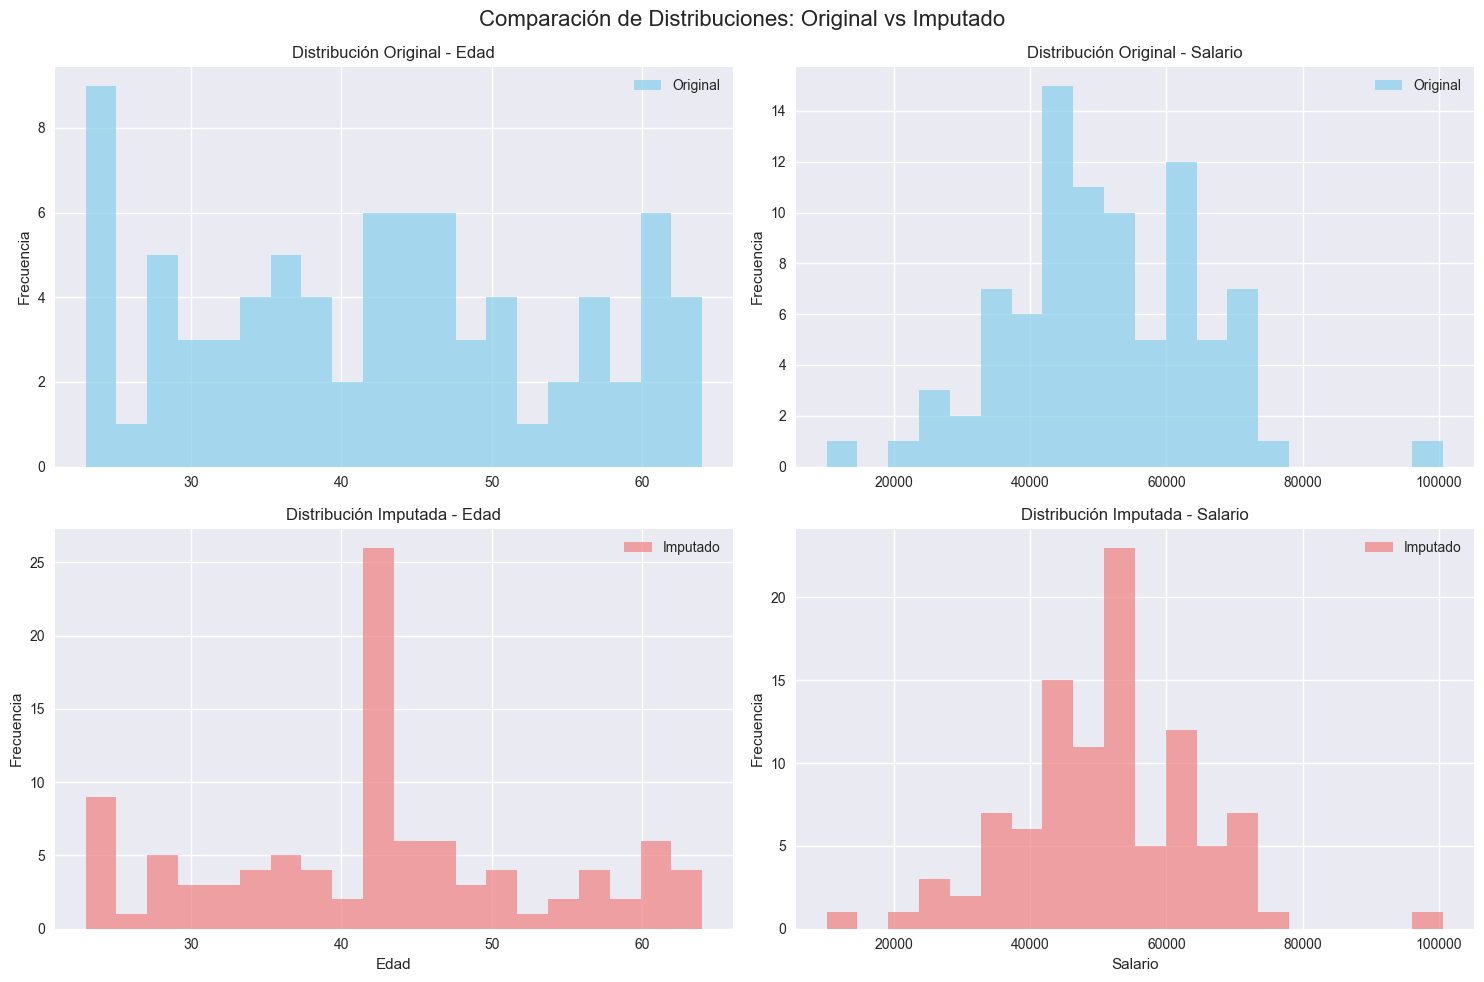


RESUMEN DE EFECTIVIDAD DEL TRATAMIENTO
Registros originales: 100
Registros después de eliminar filas con nulos: 46 (46.0%)
Registros después de imputación: 100 (100.0%)
Registros preservados con imputación: 54 adicionales


In [32]:
# Visualización de comparación antes/después
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparación de Distribuciones: Original vs Imputado', fontsize=16)

# Comparar distribuciones para variables numéricas clave
variables = ['edad', 'salario']
colors = ['skyblue', 'lightcoral']

for i, var in enumerate(variables):
    # Distribución original (sin NaNs)
    axes[0, i].hist(df_original[var].dropna(), bins=20, alpha=0.7, 
                   color=colors[0], label='Original')
    axes[0, i].set_title(f'Distribución Original - {var.title()}')
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].legend()
    
    # Distribución después de imputación
    axes[1, i].hist(df_imputado[var], bins=20, alpha=0.7, 
                   color=colors[1], label='Imputado')
    axes[1, i].set_title(f'Distribución Imputada - {var.title()}')
    axes[1, i].set_xlabel(var.title())
    axes[1, i].set_ylabel('Frecuencia')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

# Resumen final de efectividad
print("\nRESUMEN DE EFECTIVIDAD DEL TRATAMIENTO")
print("=" * 50)
filas_originales = len(df_original)
filas_sin_nulos = len(df_sin_nulos)
filas_imputadas = len(df_imputado)

print(f"Registros originales: {filas_originales}")
print(f"Registros después de eliminar filas con nulos: {filas_sin_nulos} ({((filas_sin_nulos/filas_originales)*100):.1f}%)")
print(f"Registros después de imputación: {filas_imputadas} ({((filas_imputadas/filas_originales)*100):.1f}%)")
print(f"Registros preservados con imputación: {filas_originales - filas_sin_nulos} adicionales")

## Resumen y Mejores Prácticas

### 🎯 Técnicas Aprendidas

1. **Identificación de datos faltantes:**
   - `df.isnull()`, `df.isna()`, `df.info()`
   - Análisis de patrones y porcentajes

2. **Visualización:**
   - Mapas de calor con seaborn
   - Gráficos de barras para cuantificar faltantes

3. **Estrategias de eliminación:**
   - `dropna()` con diferentes parámetros
   - Eliminación por umbral de completitud

4. **Técnicas de imputación:**
   - **Estadística básica:** media, mediana, moda
   - **Avanzada:** interpolación, forward/backward fill
   - **Por grupos:** imputación basada en categorías

### 📋 Guía de Decisión

**¿Cuándo eliminar vs imputar?**

- **Eliminar** cuando:
  - < 5% de datos faltantes
  - Los valores faltantes son completamente aleatorios
  - Tienes suficientes datos después de la eliminación

- **Imputar** cuando:
  - > 5% de datos faltantes
  - Los datos son valiosos y no puedes permitirte perderlos
  - Hay patrones identificables en los faltantes

### 🔧 Consejos Prácticos

1. **Siempre analiza el patrón** de datos faltantes antes de decidir
2. **Mantén una copia** del dataset original
3. **Documenta tus decisiones** de tratamiento
4. **Valida los resultados** comparando estadísticas antes/después
5. **Considera el contexto** del negocio al elegir la estrategia

### ⚠️ Advertencias

- La imputación puede introducir bias si no se hace correctamente
- No todas las técnicas son apropiadas para todos los tipos de datos
- Siempre considera si los datos faltantes tienen significado por sí mismos

¡Has completado exitosamente la guía de tratamiento de datos faltantes! 🎉